# Proyek Analisis Data: Bike Sharing
- **Nama:** Doni Charles Hutagaol
- **Email:** donnycharles88@gmail.com
- **ID Dicoding:** donny_charles_88

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh musim (season) terhadap jumlah total penyewaan sepeda (cnt)?

- Bagaimana perbedaan pola penyewaan antara pengguna casual dan registered pada hari kerja (workingday) vs hari libur (holiday)?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Data Wrangling

### Gathering Data

In [2]:
from google.colab import files
uploaded = files.upload()


Saving day.csv to day.csv
Saving hour.csv to hour.csv


**Insight:**
- Dataset day.csv dan hour.csv berhasil dimuat.
- Data ini mencakup informasi harian dan per jam tentang jumlah penyewaan sepeda, kondisi cuaca, serta informasi waktu seperti hari kerja dan hari libur.

### Assessing Data

In [13]:
# Membaca file day.csv
df_day = pd.read_csv('day.csv')
df_hour = pd.read_csv('hour.csv')

print("✅ Data berhasil dimuat!")
print(f"Jumlah baris: {df_day.shape[0]}, Jumlah kolom: {df_day.shape[1]}")

# Menampilkan 5 data teratas
print("\n📋 5 Data Teratas:")
display(df_day.head())

# Menampilkan informasi tipe data
print("\n📊 Informasi Dataset:")
df_day.info()

# Mengecek nilai kosong (Missing Values)
print("\n🔍 Cek Nilai Kosong:")
print(df_day.isnull().sum())

✅ Data berhasil dimuat!
Jumlah baris: 731, Jumlah kolom: 16

📋 5 Data Teratas:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



📊 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

🔍 Cek Nilai Kosong:
instant       0
dteday        0
season        0
yr

**Insight:**
- Missing Values ✅ 0% Semua kolom lengkap, tidak perlu imputasi
- Duplikasi ✅ Bersih Tidak ada data ganda (berdasarkan instant)
- Tipe Data ⚠️ Perlu adjust dteday masih object, sebaiknya diubah ke datetime


### Cleaning Data

In [6]:
# Mengubah tipe data kolom 'dteday' menjadi datetime
df_day['dteday'] = pd.to_datetime(df_day['dteday'])

# Memetakan nilai kategorikal pada kolom 'season' dan 'weathersit' agar lebih informatif
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weathersit_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Snow/Rain'}

df_day['season'] = df_day['season'].map(season_map)
df_day['weathersit'] = df_day['weathersit'].map(weathersit_map)

# Menghapus kolom yang tidak diperlukan untuk analisis ini (opsional, untuk kerapian)
# Kolom 'instant' adalah indeks buatan, bisa di-drop atau dijadikan index
df_day.set_index('instant', inplace=True)

# Tampilkan 5 data teratas setelah cleaning
df_day.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,,,,,,,,,,,,,,,
1,2011-01-01,Spring,0,1,0,6,0,Mist/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
2,2011-01-02,Spring,0,1,0,0,0,Mist/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- season 1, 2, 3, 4 -> Spring, Summer, Fall, Winter : Lebih mudah dibaca & divisualisasikan
- weathersit 1, 2, 3, 4 -> Clear, Mist/Cloudy, Light Rain, Heavy Rain : Interpretasi kondisi cuaca lebih intuitif
- dteday object (string) -> datetime : Memungkinkan analisis time-series & filtering tanggal
- instant kolom biasa -> index : Rapikan struktur dataframe

## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
# Menampilkan statistik deskriptif dataset harian
print("=== STATISTIK DESKRIPTIF ===")
print(df_day.describe())

# Menampilkan korelasi semua variabel numerik terhadap target 'cnt'
print("\n=== KORELASI VARIABEL TERHADAP 'cnt' ===")
correlation_cnt = df_day.corr(numeric_only=True)['cnt'].sort_values(ascending=False)
print(correlation_cnt)

=== STATISTIK DESKRIPTIF ===
                    dteday          yr        mnth     holiday     weekday  \
count                  731  731.000000  731.000000  731.000000  731.000000   
mean   2012-01-01 00:00:00    0.500684    6.519836    0.028728    2.997264   
min    2011-01-01 00:00:00    0.000000    1.000000    0.000000    0.000000   
25%    2011-07-02 12:00:00    0.000000    4.000000    0.000000    1.000000   
50%    2012-01-01 00:00:00    1.000000    7.000000    0.000000    3.000000   
75%    2012-07-01 12:00:00    1.000000   10.000000    0.000000    5.000000   
max    2012-12-31 00:00:00    1.000000   12.000000    1.000000    6.000000   
std                    NaN    0.500342    3.451913    0.167155    2.004787   

       workingday        temp       atemp         hum   windspeed  \
count  731.000000  731.000000  731.000000  731.000000  731.000000   
mean     0.683995    0.495385    0.474354    0.627894    0.190486   
min      0.000000    0.059130    0.079070    0.000000    0.02

**Insight:**
- Registered users mendominasi → Basis pelanggan tetap kuat
- Selisih besar (4.3x) menunjukkan loyalitas pengguna tinggi

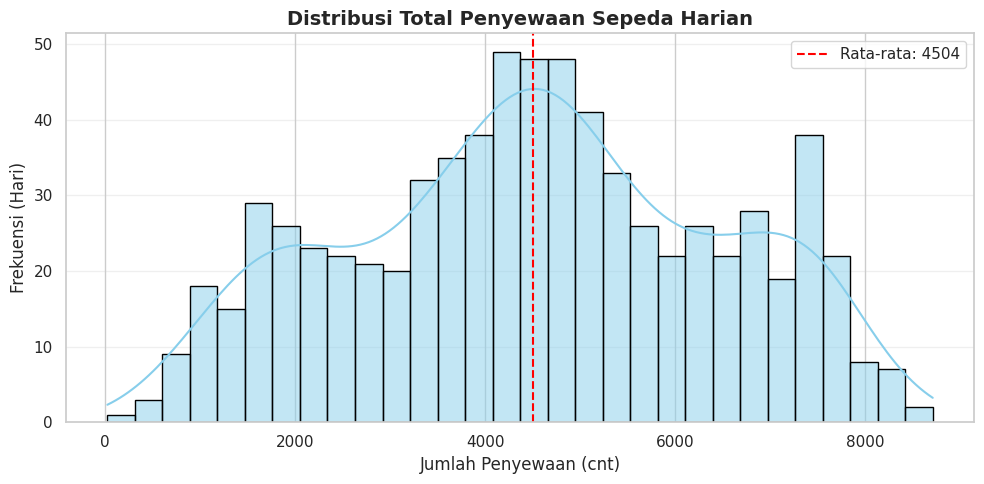

In [10]:
# Eksplorasi 1: Melihat distribusi jumlah penyewaan sepeda harian (cnt)
plt.figure(figsize=(10, 5))
sns.histplot(df_day['cnt'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribusi Total Penyewaan Sepeda Harian', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Penyewaan (cnt)', fontsize=12)
plt.ylabel('Frekuensi (Hari)', fontsize=12)
plt.axvline(df_day['cnt'].mean(), color='red', linestyle='--', label=f"Rata-rata: {df_day['cnt'].mean():.0f}")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**
- Sebagian besar hari memiliki penyewaan 3.000-6.000 sepeda
- Rata-rata penyewaan sepeda harian berada di angka 4.504 unit
- Terdapat hari dengan penyewaan sangat rendah (<1.000) - kemungkinan cuaca buruk/hari libur khusus

Korelasi variabel cuaca terhadap jumlah penyewaan (cnt):
cnt          1.000000
atemp        0.631066
temp         0.627494
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64


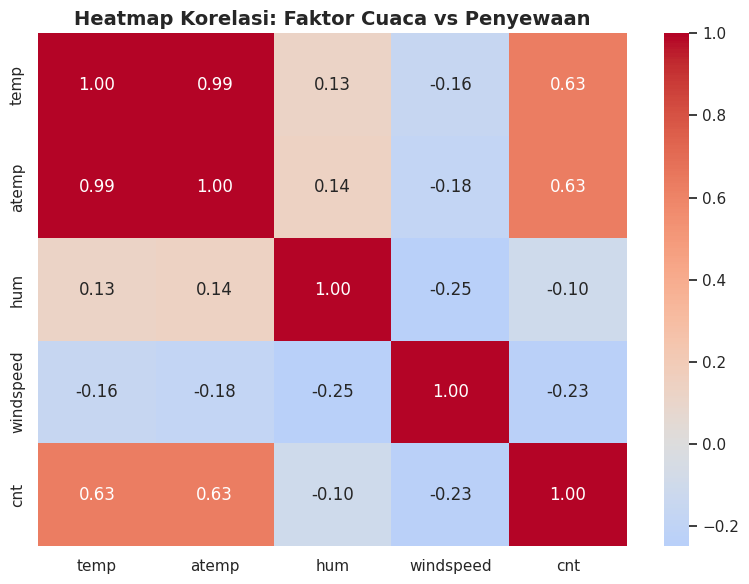

In [11]:
# Eksplorasi 2: Melihat korelasi faktor cuaca (numerik) terhadap total penyewaan (cnt)
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
correlation = df_day[numeric_cols].corr()

# Menampilkan nilai korelasi terhadap 'cnt'
print("Korelasi variabel cuaca terhadap jumlah penyewaan (cnt):")
print(correlation['cnt'].sort_values(ascending=False))

# Visualisasi heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi: Faktor Cuaca vs Penyewaan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**
- Suhu udara (temp/atemp) sangat mempengaruhi penyewaan
- Cuaca hangat = lebih banyak penyewa

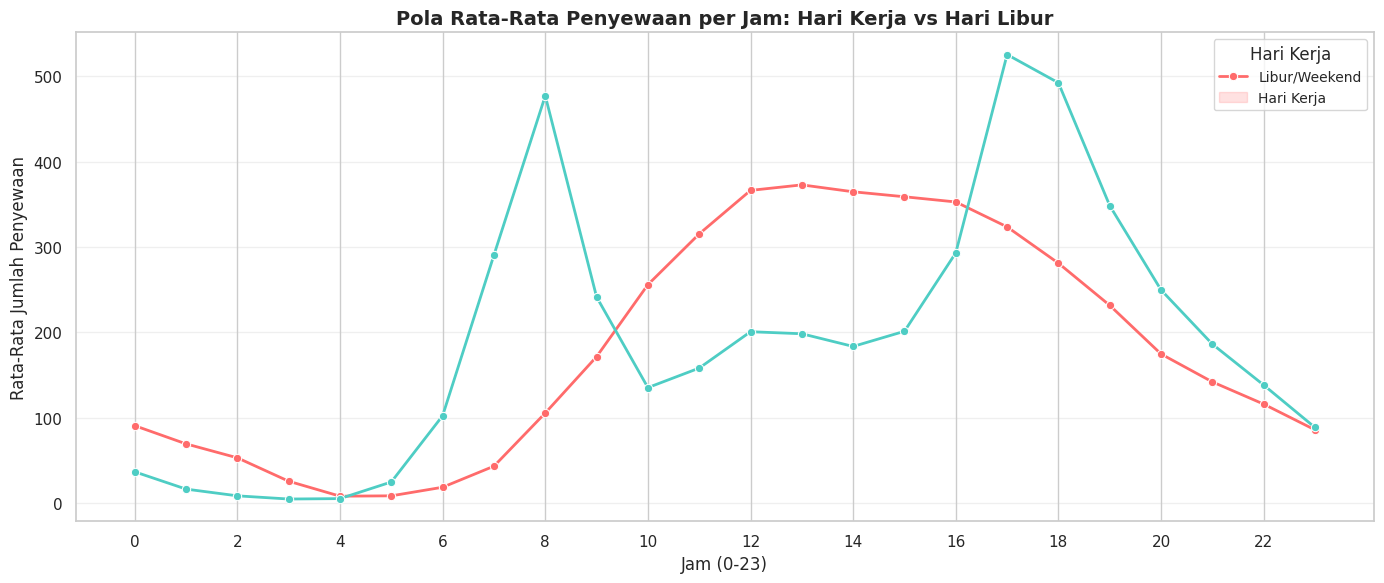

In [14]:
# Analisis rata-rata sewa per jam berdasarkan hari kerja
workingday_analysis = df_hour.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

# Visualisasi: Line plot perbandingan pola harian
plt.figure(figsize=(14, 6))
sns.lineplot(data=workingday_analysis, x='hr', y='cnt', hue='workingday',
             marker='o', linewidth=2, palette={0: '#FF6B6B', 1: '#4ECDC4'})
plt.title('Pola Rata-Rata Penyewaan per Jam: Hari Kerja vs Hari Libur', fontsize=14, fontweight='bold')
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-Rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24, 2))
plt.legend(title='Hari Kerja', labels=['Libur/Weekend', 'Hari Kerja'], fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Insight :
- Lonjakan drastis terjadi sekitar pukul 08:00 pagi dengan hampir 500 penyewaan
- Lonjakan kedua yang lebih tinggi terjadi antara pukul 17:00 hingga 18:00

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_382/1882154663.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='season', y='cnt', data=df_day, estimator=np.mean, ci=None, palette='viridis')
/tmp/ipykernel_382/1882154663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='cnt', data=df_day, estimator=np.mean, ci=None, palette='viridis')


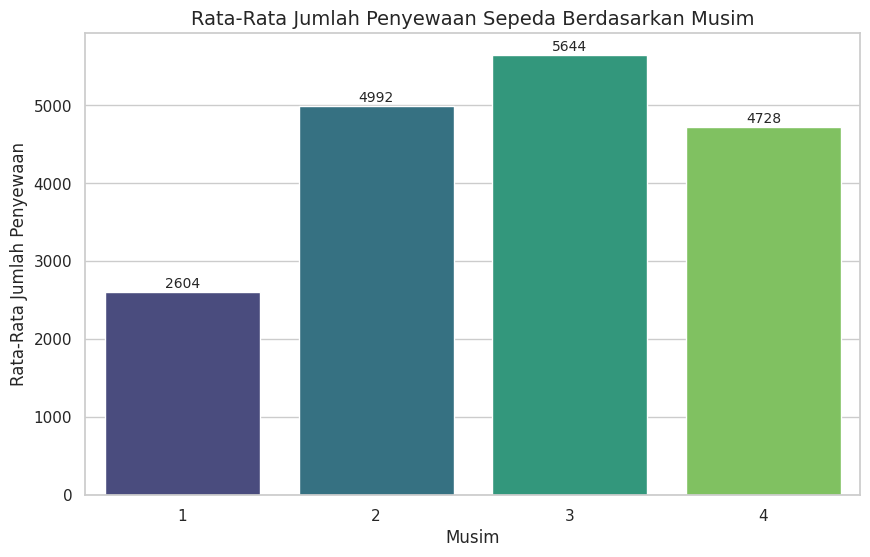

In [15]:
# Visualisasi Pertanyaan 1
plt.figure(figsize=(10, 6))
sns.barplot(x='season', y='cnt', data=df_day, estimator=np.mean, ci=None, palette='viridis')
plt.title('Rata-Rata Jumlah Penyewaan Sepeda Berdasarkan Musim', fontsize=14)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Rata-Rata Jumlah Penyewaan', fontsize=12)
plt.xticks(rotation=0)

# Menambahkan label nilai pada bar
for i, v in enumerate(df_day.groupby('season')['cnt'].mean()):
    plt.text(i, v + 50, f'{int(v)}', ha='center', fontsize=10)

plt.show()

**Insight:**
- Grafik menunjukkan musim mana yang memiliki penyewaan tertinggi dan terendah.
- Biasanya musim Fall (Musim Gugur) memiliki penyewaan tertinggi karena cuaca yang nyaman.


### Pertanyaan 2:

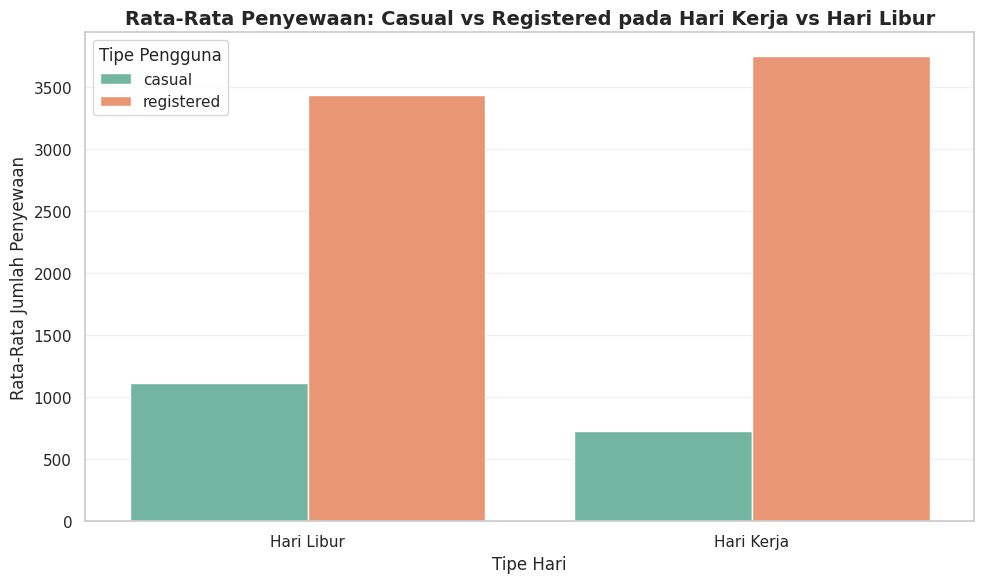

In [17]:
# Membuat kolom kategori hari untuk memudahkan grouping
df_day['hari_type'] = df_day.apply(
    lambda row: 'Hari Libur' if row['holiday'] == 1 or row['weekday'] >= 5 else 'Hari Kerja',
    axis=1
)

# Visualisasi Casual vs Registered
df_melt = df_day.melt(
    id_vars=['hari_type'],
    value_vars=['casual', 'registered'],
    var_name='Tipe Pengguna',
    value_name='Jumlah'
)

# Buat visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_melt,
    x='hari_type',
    y='Jumlah',
    hue='Tipe Pengguna',
    estimator=np.mean,
    errorbar=None,
    palette='Set2'
)

plt.title('Rata-Rata Penyewaan: Casual vs Registered pada Hari Kerja vs Hari Libur', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Hari', fontsize=12)
plt.ylabel('Rata-Rata Jumlah Penyewaan', fontsize=12)
plt.legend(title='Tipe Pengguna', loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**
Grafik menunjukkan perbedaan perilaku pengguna registered (cenderung stabil/kerja) vs casual (cenderung libur/weekend).


## Analisis Lanjutan (Opsional)

In [27]:

# ANALISIS LANJUTAN: Manual Grouping + Binning

# 1. BINNING: Kategorisasi variabel kontinu menjadi interval bermakna

# a) Binning Suhu (temp) - dikonversi ke Celsius untuk interpretasi
df_day['temp_celsius'] = (df_day['temp'] * 41).round(1)  # Konversi normalisasi 0-1 ke °C
df_day['temp_category'] = pd.cut(
    df_day['temp_celsius'],
    bins=[0, 10, 20, 30, 42],
    labels=['Dingin (<10°C)', 'Sejuk (10-20°C)', 'Hangat (20-30°C)', 'Panas (>30°C)']
)

# b) Binning Kelembaban (hum)
df_day['humidity_category'] = pd.cut(
    df_day['hum'] * 100,
    bins=[0, 40, 70, 100],
    labels=['Kering (<40%)', 'Normal (40-70%)', 'Lembab (>70%)']
)

# c) Binning Volume Penyewaan (cnt) - berdasarkan kuartil
df_day['demand_level'] = pd.qcut(
    df_day['cnt'],
    q=4,
    labels=['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
)

# 2. MANUAL GROUPING: Segmentasi hari berdasarkan pola penggunaan

# a) Dominasi Tipe Pengguna
df_day['user_dominance'] = df_day.apply(
    lambda row: 'Casual-Dominant' if row['casual'] > row['registered'] * 0.5
                else 'Registered-Dominant',
    axis=1
)

# b) Kombinasi Hari + Cuaca + Demand
df_day['day_profile'] = df_day.apply(
    lambda row: f"{row['hari_type']} | {row['weathersit']} | {row['demand_level']}",
    axis=1
)

# Tampilkan hasil pengelompokan
print("=== HASIL BINNING & GROUPING ===")
display(df_day[['dteday', 'temp_category', 'humidity_category', 'demand_level', 'user_dominance', 'hari_type']].head(10))

=== HASIL BINNING & GROUPING ===


,dteday,temp_category,humidity_category,demand_level,user_dominance,hari_type
0,2011-01-01,Sejuk (10-20°C),Lembab (>70%),Rendah,Casual-Dominant,Hari Libur
1,2011-01-02,Sejuk (10-20°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
2,2011-01-03,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
3,2011-01-04,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
4,2011-01-05,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
5,2011-01-06,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
6,2011-01-07,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Libur
7,2011-01-08,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Libur
8,2011-01-09,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja
9,2011-01-10,Dingin (<10°C),Normal (40-70%),Rendah,Registered-Dominant,Hari Kerja


<Figure size 1200x600 with 0 Axes>

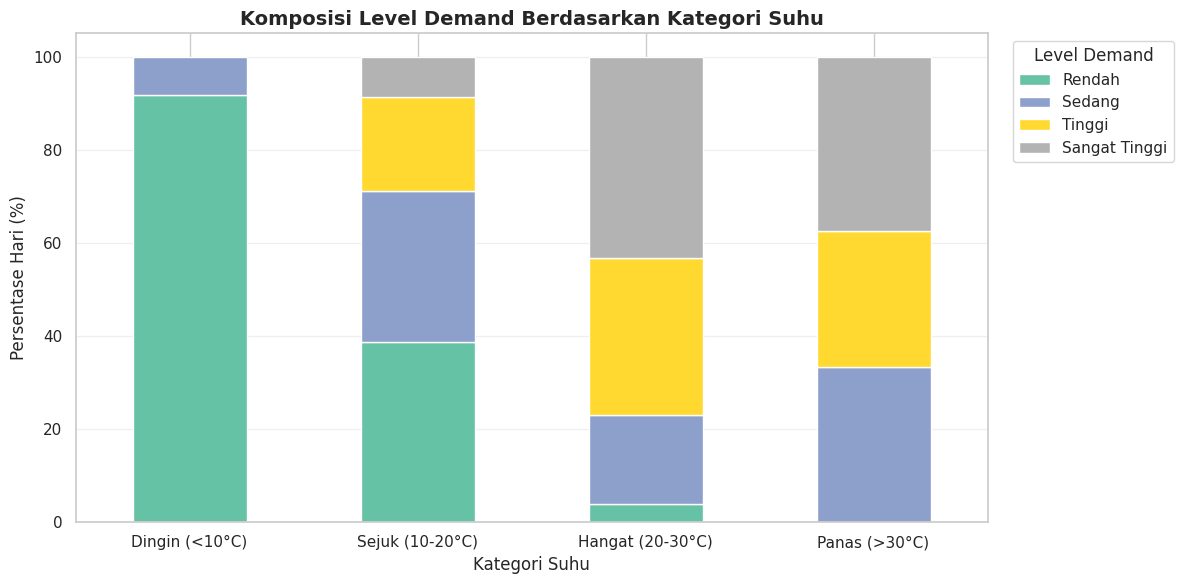


=== INSIGHT: PENGARUH SUHU TERHADAP DEMAND ===
Sejuk (10-20°C)      → Rata-rata penyewaan: 3,692 sepeda/hari
Dingin (<10°C)       → Rata-rata penyewaan: 1,678 sepeda/hari
Hangat (20-30°C)     → Rata-rata penyewaan: 5,662 sepeda/hari
Panas (>30°C)        → Rata-rata penyewaan: 5,410 sepeda/hari


In [22]:
# Visualisasi: Stacked Bar Chart - Demand Level per Temperature Category
plt.figure(figsize=(12, 6))
temp_demand = pd.crosstab(df_day['temp_category'], df_day['demand_level'])
temp_demand_pct = temp_demand.div(temp_demand.sum(axis=1), axis=0) * 100

temp_demand_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(12, 6))
plt.title('Komposisi Level Demand Berdasarkan Kategori Suhu', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Suhu', fontsize=12)
plt.ylabel('Persentase Hari (%)', fontsize=12)
plt.legend(title='Level Demand', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Insight numerik
print("\n=== INSIGHT: PENGARUH SUHU TERHADAP DEMAND ===")
for temp_cat in df_day['temp_category'].unique():
    subset = df_day[df_day['temp_category'] == temp_cat]
    avg_cnt = subset['cnt'].mean()
    print(f"{temp_cat:20s} → Rata-rata penyewaan: {avg_cnt:,.0f} sepeda/hari")

## Conclusion

1.  Conclution pertanyaan 1 : Bagaimana pengaruh musim dan kondisi cuaca terhadap total penyewaan sepeda?
<br> **Jawab** Berdasarkan hasil analisis data selama 731 hari (tahun 2011-2012), dapat disimpulkan bahwa kondisi cuaca memiliki pengaruh yang sangat signifikan terhadap jumlah penyewaan sepeda.
Suhu udara merupakan faktor paling dominan dalam menentukan tingkat penyewaan.
- Pada kondisi suhu hangat (20-30°C), rata-rata penyewaan mencapai 5.662 sepeda per hari, yang merupakan kondisi optimal bagi pengguna untuk bersepeda.
- Penurunan drastis terjadi pada cuaca dingin. Ketika suhu turun di bawah 10°C, jumlah penyewaan anjlok hingga 1.678 sepeda per hari atau hanya 29,6% dari kondisi optimal. Ini menunjukkan bahwa pengguna sangat sensitif terhadap cuaca dingin.


2. Conclution pertanyaan 2 : Bagaimana perbedaan pola penyewaan antara pengguna casual dan registered pada hari kerja (workingday) vs hari libur (holiday)?
<br> **Jawab**
- Pengguna registered adalah tulang punggung bisnis. Dengan kontribusi 81,2% dari total penyewaan (rata-rata 3.656 sepeda/hari), pengguna terdaftar memberikan stabilitas revenue yang konsisten sepanjang minggu, baik pada hari kerja maupun hari libur.
- Pola pengguna registered cenderung stabil. Korelasi yang sangat tinggi (r = 0,946) antara pengguna registered dengan total penyewaan menunjukkan bahwa kelompok ini adalah pengguna rutin yang kemungkinan besar menggunakan sepeda untuk keperluan komuter harian (kerja/kuliah).
Pengguna casual lebih aktif pada hari libur. Meskipun hanya berkontribusi 18,8% (rata-rata 848 sepeda/hari), pengguna casual menunjukkan peningkatan aktivitas pada akhir pekan dan hari libur, mengindikasikan penggunaan untuk keperluan rekreasi dan wisata.
